Model 1 : Predictors of a Cost Burdened Home

Accuracy Score: 0.9084680252986648

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.92      0.92      3407
         1.0       0.88      0.89      0.89      2285

    accuracy                           0.91      5692
   macro avg       0.90      0.91      0.91      5692
weighted avg       0.91      0.91      0.91      5692



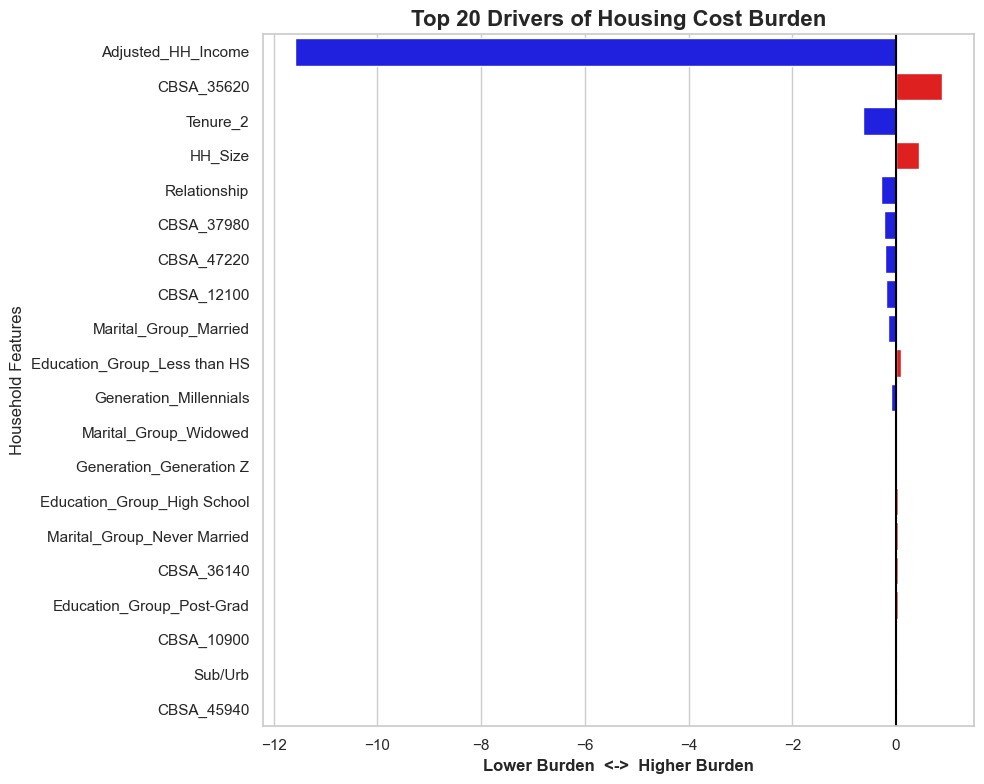

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
merged = pd.read_csv('MERGED_GENERATIONS.csv')

working_gens = ['Baby Boomers', 'Generation X', 'Millennials', 'Generation Z']
df_filtered = merged[merged['Generation'].isin(working_gens)].copy()

df_filtered = df_filtered[df_filtered['Tenure'] != 3]
df_filtered['CBSA'] = df_filtered['CBSA'].astype(str)

def education_bins(edu_code):

    if edu_code <= 38:
        return 'Less than HS'
    elif edu_code == 39:
        return 'High School'
    elif edu_code in [40, 41, 42, 43]:
        return 'College'
    elif edu_code >= 44:
        return 'Post-Grad'
    else:
        return 'Unknown'
    
def categorize_marital(mar_code):

    if mar_code in [1, 2, 3]:
        return 'Married'
    elif mar_code == 4:
        return 'Widowed'
    elif mar_code in [5, 6]:
        return 'Divorced/Separated'
    elif mar_code == 7:
        return 'Never Married'
    else:
        return 'Unknown'

df_filtered['Marital_Group'] = df_filtered['Marital'].apply(categorize_marital)
df_filtered['Education_Group'] = df_filtered['Education'].apply(education_bins)

features = ['Adjusted_HH_Income', 'Sub/Urb', 'HH_Size', 'Relationship', 
    'Generation', 'CBSA', 'Tenure', 'Education_Group', 'Marital_Group', 
    'Is_Cost_Burdened']

df_model = df_filtered[features].dropna()
df_model = pd.get_dummies(df_model, columns=['Generation', 'CBSA', 'Tenure', 'Education_Group', 'Marital_Group'], drop_first=True)

y = df_model['Is_Cost_Burdened']
X = df_model.drop(columns=['Is_Cost_Burdened'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

print("Accuracy Score:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

features = X_train.columns
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': features,
    'Weight': coefficients
})


feature_importance['Absolute_Weight'] = feature_importance['Weight'].abs()

feature_importance = feature_importance.sort_values(by='Absolute_Weight', ascending=False)

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.set_theme(style="whitegrid")

colors = top_features['Weight'].apply(lambda x: 'red' if x > 0 else 'blue')

sns.barplot(
    data=top_features, x='Weight', y='Feature', palette=colors.tolist()
)

plt.title("Top 20 Drivers of Housing Cost Burden", fontsize=16, fontweight='bold')
plt.xlabel("Lower Burden  <->  Higher Burden", fontsize=12, fontweight='bold')
plt.ylabel("Household Features", fontsize=12)

plt.axvline(0, color='black', linewidth=1.5) 

plt.tight_layout()
plt.savefig('Top20_Drivers.png')
plt.show()

Model 2 : Predicting a Renter/Owner based on Income/Financials

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore') 

df = pd.read_csv('MERGED_GENERATIONS.csv')

df = df[df['Tenure'] != 3].copy()
df['Is_Owner'] = (df['Tenure'] == 1).astype(int) 

features = ['Adjusted_HH_Income', 'Age', 'Year', 'CBSA']
df_model = df[features + ['Is_Owner']].dropna()
df_model['CBSA'] = df_model['CBSA'].astype(str)


df_model = pd.get_dummies(df_model, columns=['CBSA'], drop_first=True)

y = df_model['Is_Owner']

X = df_model.drop(columns=['Is_Owner'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

print("Accuracy Score:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

def test_predictions(income, age, year, cbsa):

    profile = {col: 0 for col in X_train.columns}

    profile['Age'] = age
    profile['Adjusted_HH_Income'] = income
    profile['Year'] = year

    cbsa_col = f"CBSA_{cbsa}"

    if cbsa_col in profile:

        profile[cbsa_col] = 1

    profile_df = pd.DataFrame([profile])
    profile_scaled = pd.DataFrame(scaler.transform(profile_df), columns=profile_df.columns)

    prob_owner = model.predict_proba(profile_scaled)[0][1]
    return prob_owner



Accuracy Score: 0.7659308621407747

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.50      0.58      2321
           1       0.79      0.89      0.84      4882

    accuracy                           0.77      7203
   macro avg       0.74      0.69      0.71      7203
weighted avg       0.76      0.77      0.75      7203



In [29]:
import pandas as pd

personas = [
    {"Label": "Young & Poor", "Age": 26, "Income": 35000},
    {"Label": "Young & Rich", "Age": 26, "Income": 145000},
    {"Label": "Older & Poor", "Age": 62, "Income": 35000},
    {"Label": "Older & Rich", "Age": 62, "Income": 145000}
]

regions = {
    "35620": "NYC-Newark-Jersey City (Urban)",
    "47220": "Vineland-Bridgeton (Rural)"
}

results = []

for cbsa_code, region_name in regions.items():
    for person in personas:

        prob_2005 = test_predictions(person['Income'], person['Age'], 2005, cbsa_code)
        prob_2023 = test_predictions(person['Income'], person['Age'],  2023, cbsa_code)
        
        drop_pct = prob_2005 - prob_2023
        
        results.append({
            "Region": region_name,
            "Persona": person["Label"],
            "Age": person["Age"],
            "Income": f"${person['Income']:,}",
            "2005 Own %": f"{prob_2005:.1%}",
            "2023 Own %": f"{prob_2023:.1%}",
            "Net Change": f"{(drop_pct * -100):.1f}%" 
        })

df_scenarios = pd.DataFrame(results)
display(df_scenarios)

,Region,Persona,Age,Income,2005 Own %,2023 Own %,Net Change
0,NYC-Newark-Jersey City (Urban),Young & Poor,26,"$35,000",24.3%,14.2%,-10.1%
1,NYC-Newark-Jersey City (Urban),Young & Rich,26,"$145,000",56.6%,40.3%,-16.3%
2,NYC-Newark-Jersey City (Urban),Older & Poor,62,"$35,000",64.5%,48.5%,-16.1%
3,NYC-Newark-Jersey City (Urban),Older & Rich,62,"$145,000",88.1%,79.3%,-8.8%
4,Vineland-Bridgeton (Rural),Young & Poor,26,"$35,000",30.0%,18.1%,-11.9%
5,Vineland-Bridgeton (Rural),Young & Rich,26,"$145,000",63.5%,47.4%,-16.1%
6,Vineland-Bridgeton (Rural),Older & Poor,62,"$35,000",70.9%,55.7%,-15.2%
7,Vineland-Bridgeton (Rural),Older & Rich,62,"$145,000",90.8%,83.7%,-7.2%


3. Time Series Forecasting

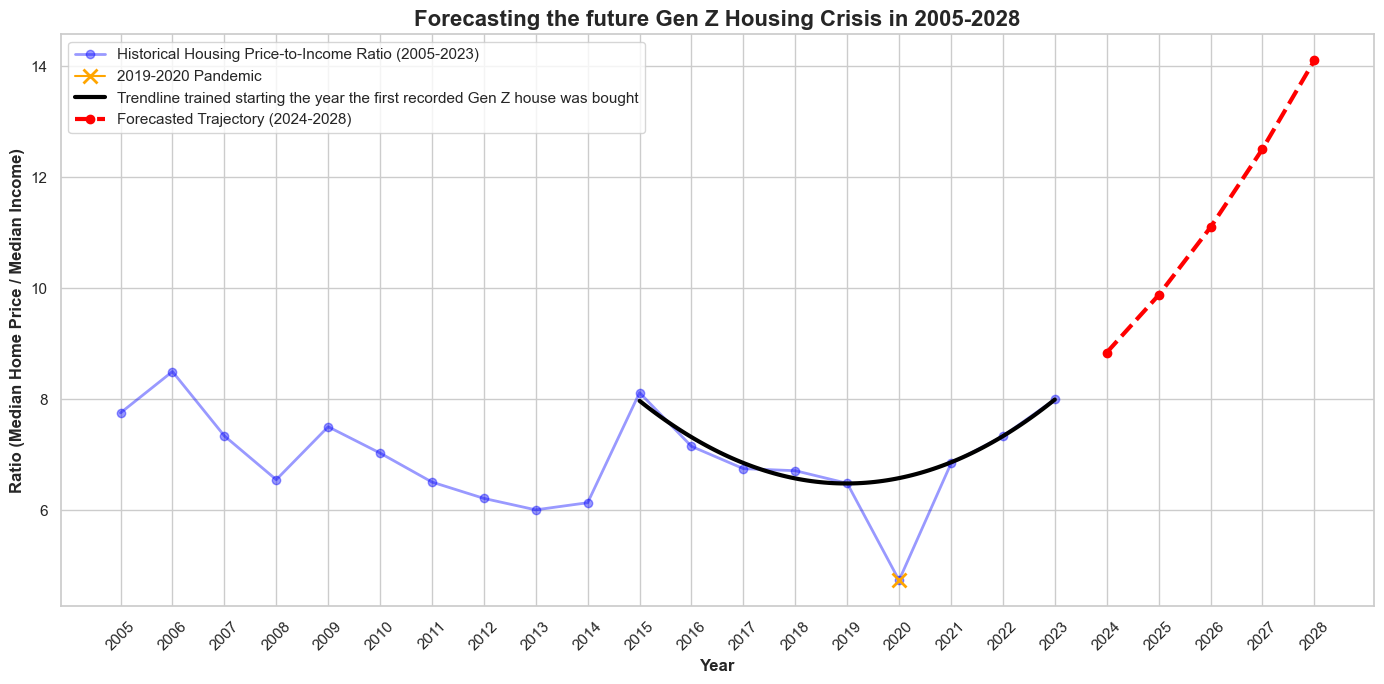

2024: Predicted Price-to-Income Ratio of 8.84
2025: Predicted Price-to-Income Ratio of 9.88
2026: Predicted Price-to-Income Ratio of 11.10
2027: Predicted Price-to-Income Ratio of 12.51
2028: Predicted Price-to-Income Ratio of 14.11


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('MERGED_GENERATIONS.csv')

df_young_adults = df[(df['Age'] >= 22) & (df['Age'] <= 35)]

yearly_data = df_young_adults.groupby('Year').agg({
    'Adjusted_HH_Income': 'median',
    'Adjusted_Estimated_Median_Home_Price': 'median' 
}).reset_index()

yearly_data['Price_to_Income_Ratio'] = yearly_data['Adjusted_Estimated_Median_Home_Price'] / yearly_data['Adjusted_HH_Income']

ts_data = yearly_data.set_index('Year')['Price_to_Income_Ratio']
ts_data_visual = ts_data[(ts_data.index >= 2005) & (ts_data.index <= 2023)]

# Training on EDA data where Generation Z first recorded house purchase was 2015 at 18 years old, drop 2020 covid 
ts_data_model = ts_data[(ts_data.index >= 2015) & (ts_data.index <= 2023) & (ts_data.index != 2020)]

model_years = np.array(ts_data_model.index)
model_ratios = ts_data_model.values

weights = np.exp((model_years - model_years.min()) * 0.2) 
z = np.polyfit(model_years, model_ratios, 2, w=weights)
trend_function = np.poly1d(z)

smooth_years = np.linspace(model_years.min(), model_years.max(), 100)
historical_curve = trend_function(smooth_years)

forecast_steps = 5
future_years = np.array(range(2024, 2024 + forecast_steps))
forecast_ratios = trend_function(future_years)

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

plt.plot(ts_data_visual.index, ts_data_visual.values, marker='o', color='blue', alpha=0.4, linewidth=2, label='Historical Housing Price-to-Income Ratio (2005-2023)')

if 2020 in ts_data_visual.index:
    plt.plot(2020, ts_data_visual.loc[2020], marker='x', color='orange', markersize=10, mew=2, label='2019-2020 Pandemic')

plt.plot(smooth_years, historical_curve, color='black', linewidth=3, label='Trendline trained starting the year the first recorded Gen Z house was bought')
plt.plot(future_years, forecast_ratios, marker='o', color='red', linestyle='--', linewidth=3, label='Forecasted Trajectory (2024-2028)')

plt.title("Forecasting the future Gen Z Housing Crisis in 2005-2028", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Ratio (Median Home Price / Median Income)", fontsize=12, fontweight='bold')

all_years = list(range(2005, 2024 + forecast_steps))
plt.xticks(all_years, rotation=45)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('Forecasting_Gen_Z_Housing.png')
plt.show()


for year, value in zip(future_years, forecast_ratios):
    print(f"{year}: Predicted Price-to-Income Ratio of {value:.2f}")